In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [155]:
df = pd.read_csv('/content/Sheet 1-Table 1.csv')

# **DATA CLEANING**

In [156]:
df.head()

,SR NO,INV NO,INV DATE,INVOICE TIME,MONTH,CUSTOMER,MOBILE,GST NO,PAN,CATEGORY,...,FINANCE,FINANCE NAME,SFID,WALLET NAME,CREDIT,PURCHASE DATE,STATE CODE,STATE NAME,REMARK,STATUS
0,1,T104/2292/22-23,01-01-2023,12.44.27 PM,23-Jan,SHEKHER,9359977163,NaN,NaN,SMART WATCH,...,0,NaN,NaN,NaN,0,05-12-2022,27,MAHARASHTRA,NaN,B to B
1,3,T104/2294/22-23,01-01-2023,3.04.30 PM,23-Jan,MADHUPAL,9123861827,NaN,NaN,MOBILE,...,0,NaN,NaN,NaN,0,07-12-2022,27,MAHARASHTRA,NaN,B to B
2,4,T104/2295/22-23,01-01-2023,4.52.02 PM,23-Jan,SALE CASH,0,NaN,NaN,EARPHONE,...,0,NaN,NaN,NaN,0,20-12-2022,27,MAHARASHTRA,NaN,B to B
3,2,T104/2293/22-23,01-01-2023,2.51.32 PM,23-Jan,VISHAL TAKKEKAR,8291065992,NaN,NaN,MOBILE,...,7299,HDB FINANCIAL,1.07E+11,NaN,0,16-11-2022,27,MAHARASHTRA,NaN,B to B
4,6,T104/2297/22-23,02-01-2023,2.50.26 PM,23-Jan,PARMILA,7710828964,NaN,NaN,MEMORY CARD,...,0,NaN,NaN,NaN,0,12-08-2022,27,MAHARASHTRA,NaN,B to B


In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2478 entries, 0 to 2477
Data columns (total 39 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SR NO               2478 non-null   int64  
 1   INV NO              2478 non-null   object 
 2   INV DATE            2478 non-null   object 
 3   INVOICE TIME        2478 non-null   object 
 4   MONTH               2478 non-null   object 
 5   CUSTOMER            2478 non-null   object 
 6   MOBILE              2478 non-null   int64  
 7   GST NO              416 non-null    object 
 8   PAN                 417 non-null    object 
 9   CATEGORY            2478 non-null   object 
 10  BRAND               2478 non-null   object 
 11  MODEL               2478 non-null   object 
 12  COLOR               2478 non-null   object 
 13  QUANTITY            2478 non-null   int64  
 14  SALE RATE           2478 non-null   float64
 15  GST(%)              2478 non-null   int64  
 16  CGST  

In [158]:

df['INV DATE'] = df['INV DATE'].astype(str)
df['INV DATE'] = pd.to_datetime(df['INV DATE'], format='%d-%m-%Y', dayfirst=True)
df['PURCHASE DATE'] = df['PURCHASE DATE'].astype(str)
df['PURCHASE DATE'] = pd.to_datetime(df['PURCHASE DATE'], format='%d-%m-%Y', dayfirst=True)



In [159]:
df.head()

,SR NO,INV NO,INV DATE,INVOICE TIME,MONTH,CUSTOMER,MOBILE,GST NO,PAN,CATEGORY,...,FINANCE,FINANCE NAME,SFID,WALLET NAME,CREDIT,PURCHASE DATE,STATE CODE,STATE NAME,REMARK,STATUS
0,1,T104/2292/22-23,2023-01-01,12.44.27 PM,23-Jan,SHEKHER,9359977163,NaN,NaN,SMART WATCH,...,0,NaN,NaN,NaN,0,2022-12-05,27,MAHARASHTRA,NaN,B to B
1,3,T104/2294/22-23,2023-01-01,3.04.30 PM,23-Jan,MADHUPAL,9123861827,NaN,NaN,MOBILE,...,0,NaN,NaN,NaN,0,2022-12-07,27,MAHARASHTRA,NaN,B to B
2,4,T104/2295/22-23,2023-01-01,4.52.02 PM,23-Jan,SALE CASH,0,NaN,NaN,EARPHONE,...,0,NaN,NaN,NaN,0,2022-12-20,27,MAHARASHTRA,NaN,B to B
3,2,T104/2293/22-23,2023-01-01,2.51.32 PM,23-Jan,VISHAL TAKKEKAR,8291065992,NaN,NaN,MOBILE,...,7299,HDB FINANCIAL,1.07E+11,NaN,0,2022-11-16,27,MAHARASHTRA,NaN,B to B
4,6,T104/2297/22-23,2023-01-02,2.50.26 PM,23-Jan,PARMILA,7710828964,NaN,NaN,MEMORY CARD,...,0,NaN,NaN,NaN,0,2022-08-12,27,MAHARASHTRA,NaN,B to B


In [160]:
df = df.drop(['INVOICE TIME' , 'MONTH' , 'GST NO','PAN','GST(%)','CGST','SGST','IGST','IMEI','BARCODE','STATE CODE','STATE NAME' , 'REMARK','MOBILE'], axis=1)

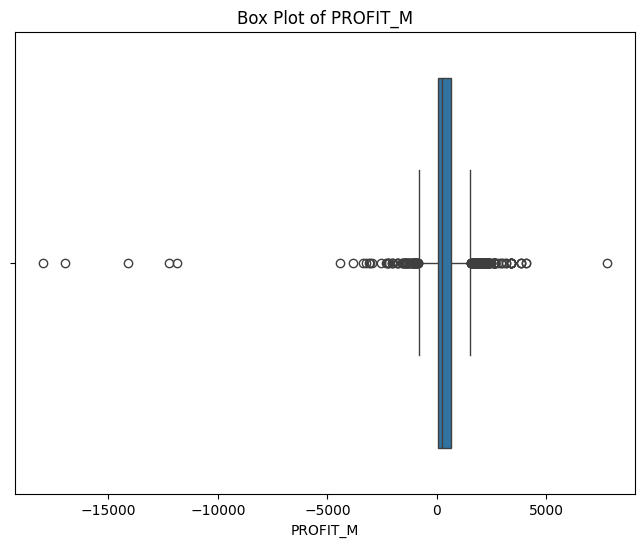

In [161]:
# Create the box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['PROFIT_M'])
plt.title('Box Plot of PROFIT_M')
plt.xlabel('PROFIT_M')
plt.show()

In [162]:
df['Give Away'] = df['PROFIT_M'].apply(lambda x: 0 if x >= 0 else -x)


In [163]:
df['PROFIT_M'] = df['PROFIT_M'].apply(lambda x: 0 if x < 0 else x)


In [164]:
df.head()

,SR NO,INV NO,INV DATE,CUSTOMER,CATEGORY,BRAND,MODEL,COLOR,QUANTITY,SALE RATE,...,CREDIT/DEBIT CARD,WALLET,FINANCE,FINANCE NAME,SFID,WALLET NAME,CREDIT,PURCHASE DATE,STATUS,Give Away
0,1,T104/2292/22-23,2023-01-01,SHEKHER,SMART WATCH,PTRON,PULSEFIT P261,BLACK GOLD,1,1355.08,...,0,0,0,NaN,NaN,NaN,0,2022-12-05,B to B,0.00000
1,3,T104/2294/22-23,2023-01-01,MADHUPAL,MOBILE,OPPO,CPH 2455 F21S PRO 5G 8+128GB,DAWNLIGHT GOLD,1,21186.44,...,0,0,0,NaN,NaN,NaN,0,2022-12-07,B to B,0.00000
2,4,T104/2295/22-23,2023-01-01,SALE CASH,EARPHONE,RIVERSONG,EA59 MELODY J,NONE,1,0.85,...,0,0,0,NaN,NaN,NaN,0,2022-12-20,B to B,64.11998
3,2,T104/2293/22-23,2023-01-01,VISHAL TAKKEKAR,MOBILE,MI,REDMI A1+ 2+32GB,BLACK,1,6355.08,...,0,0,7299,HDB FINANCIAL,1.07E+11,NaN,0,2022-11-16,B to B,0.00000
4,6,T104/2297/22-23,2023-01-02,PARMILA,MEMORY CARD,SANDISK,32GB ULTRA 120MB/S A1,NONE,1,338.98,...,0,0,0,NaN,NaN,NaN,0,2022-08-12,B to B,0.00000


In [165]:
df['CATEGORY'].unique()

array(['SMART WATCH', 'MOBILE', 'EARPHONE', 'MEMORY CARD', 'CABLE',
       'POWER BANK', 'BLUETOOTH', 'ADAPTER', 'PEN DRIVE', 'TWS',
       'NECKBAND', 'TABLET', 'CHARGER', 'TABLET S', 'ACCESSORIES',
       'SMART WATCH S', 'PORTABLE SPEAKER', 'SMART ADAPTER', 'DEMO',
       'CONNECTOR', 'CAR CHARGER', 'LAPTOP', 'BAG'], dtype=object)

In [166]:
replace_values = ['EARPHONE' , 'CABLE' , 'POWER BANK' , 'BLUETOOTH' , 'ADAPTER' , 'PEN DRIVE' , 'NECKBAND' , 'CHARGER' , 'SMART ADAPTER' , 'CONNECTOR' , 'CAR CHARGER' , 'BAG','MEMORY CARD','PORTABLE SPEAKER']
df['CATEGORY'] = df['CATEGORY'].replace(replace_values, 'ACCESSORIES')
df['CATEGORY'] = df['CATEGORY'].replace('SMART WATCH S', 'SMART WATCH')
df['CATEGORY'] = df['CATEGORY'].replace('TABLET S', 'TABLET')
df['CATEGORY'].unique()

array(['SMART WATCH', 'MOBILE', 'ACCESSORIES', 'TWS', 'TABLET', 'DEMO',
       'LAPTOP'], dtype=object)

In [167]:
df['BRAND'].unique()

array(['PTRON', 'OPPO', 'RIVERSONG', 'MI', 'SANDISK', 'SAMSUNG', 'NOKIA',
       'BOAT', 'VIVO', 'PORTRONICS', 'APPLE', 'ITEL', 'REALME', 'SYSKA',
       'NOISE', 'SONY', 'ONEPLUS', 'TECNO', 'FIRE BOLTT', 'SENNHEISER',
       'GIZMORE', 'NOTHING', 'OMTHING', 'MINIX', 'INTEX', 'HP', 'DEFY',
       'POCO', 'STUFFCOOL', 'MICROMAX', 'MOTOROLA', 'CONEKT'],
      dtype=object)

In [168]:
df['STATUS'] = df['STATUS'].replace('B to B', 'B to C')
df['STATUS'] = df['STATUS'].replace('B to F', 'B to B')
df["STATUS"].unique()

array(['B to C', 'B to B'], dtype=object)

In [169]:
df['DAYS IN STOCK'] = (df['INV DATE'] - df['PURCHASE DATE']).dt.days


In [170]:
df.head()

,SR NO,INV NO,INV DATE,CUSTOMER,CATEGORY,BRAND,MODEL,COLOR,QUANTITY,SALE RATE,...,WALLET,FINANCE,FINANCE NAME,SFID,WALLET NAME,CREDIT,PURCHASE DATE,STATUS,Give Away,DAYS IN STOCK
0,1,T104/2292/22-23,2023-01-01,SHEKHER,SMART WATCH,PTRON,PULSEFIT P261,BLACK GOLD,1,1355.08,...,0,0,NaN,NaN,NaN,0,2022-12-05,B to C,0.00000,27
1,3,T104/2294/22-23,2023-01-01,MADHUPAL,MOBILE,OPPO,CPH 2455 F21S PRO 5G 8+128GB,DAWNLIGHT GOLD,1,21186.44,...,0,0,NaN,NaN,NaN,0,2022-12-07,B to C,0.00000,25
2,4,T104/2295/22-23,2023-01-01,SALE CASH,ACCESSORIES,RIVERSONG,EA59 MELODY J,NONE,1,0.85,...,0,0,NaN,NaN,NaN,0,2022-12-20,B to C,64.11998,12
3,2,T104/2293/22-23,2023-01-01,VISHAL TAKKEKAR,MOBILE,MI,REDMI A1+ 2+32GB,BLACK,1,6355.08,...,0,7299,HDB FINANCIAL,1.07E+11,NaN,0,2022-11-16,B to C,0.00000,46
4,6,T104/2297/22-23,2023-01-02,PARMILA,ACCESSORIES,SANDISK,32GB ULTRA 120MB/S A1,NONE,1,338.98,...,0,0,NaN,NaN,NaN,0,2022-08-12,B to C,0.00000,143


In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2478 entries, 0 to 2477
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   SR NO               2478 non-null   int64         
 1   INV NO              2478 non-null   object        
 2   INV DATE            2478 non-null   datetime64[ns]
 3   CUSTOMER            2478 non-null   object        
 4   CATEGORY            2478 non-null   object        
 5   BRAND               2478 non-null   object        
 6   MODEL               2478 non-null   object        
 7   COLOR               2478 non-null   object        
 8   QUANTITY            2478 non-null   int64         
 9   SALE RATE           2478 non-null   float64       
 10  SALE PRICE(INC)     2478 non-null   int64         
 11  Unnamed: 20         0 non-null      float64       
 12  PURCHASE PRICE(PD)  2478 non-null   float64       
 13  PROFIT_M            2478 non-null   float64     

# **Sales Performance Analysis**

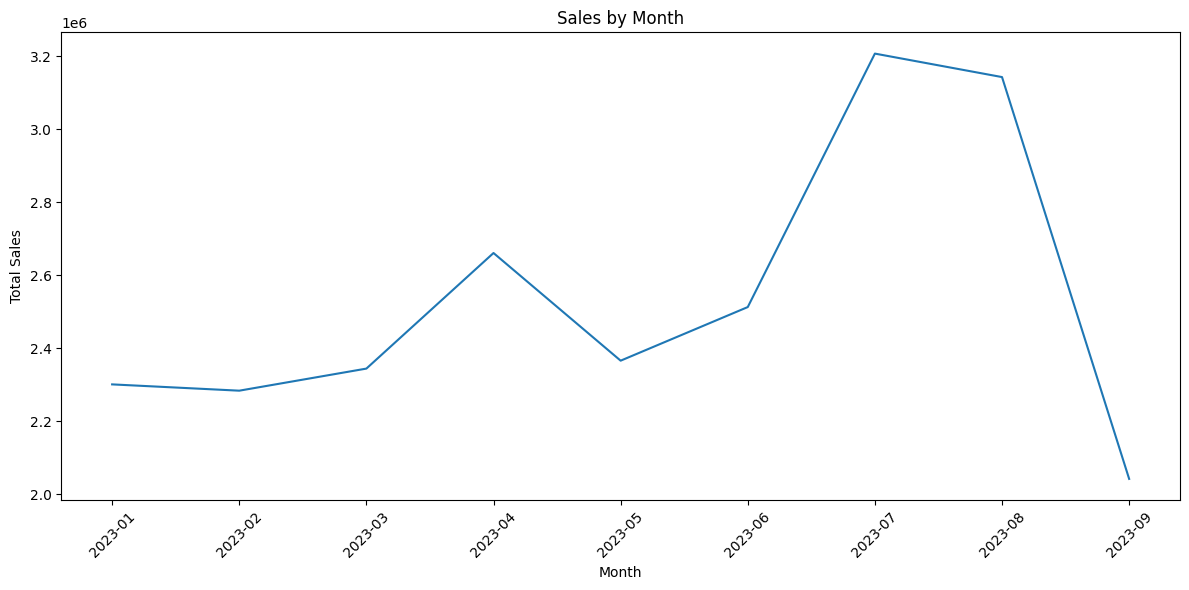

In [172]:
# Create a 'Month' column from the 'INV DATE' column
df['Month'] = df['INV DATE'].dt.to_period('M')

# Group by month and sum the 'SALE PRICE(INC)'
monthly_sales = df.groupby('Month')['SALE PRICE(INC)'].sum()

# Create the plot
plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_sales.index.astype(str), y=monthly_sales.values)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Sales by Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

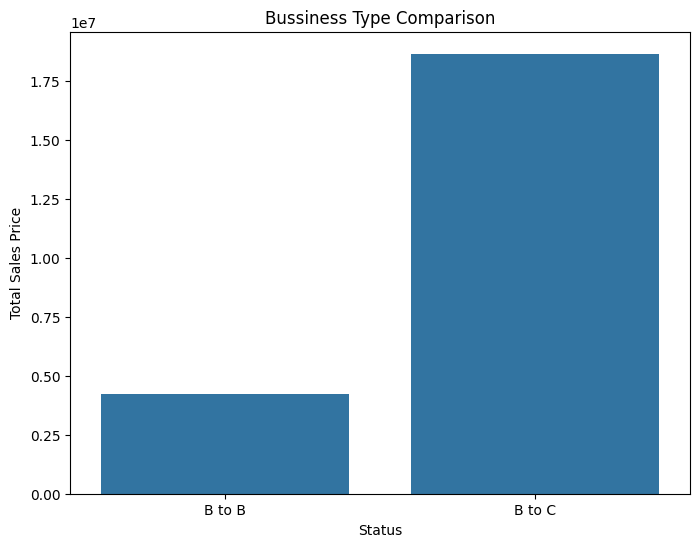

,SALE PRICE(INC)
STATUS,
B to B,4207562
B to C,18653549


In [173]:
# Group by 'STATUS' and sum the 'SALE PRICE(INC)'
status_sales = df.groupby('STATUS')['SALE PRICE(INC)'].sum()

# Create the plot
plt.figure(figsize=(8, 6))
sns.barplot(x=status_sales.index, y=status_sales.values)
plt.xlabel('Status')
plt.ylabel('Total Sales Price')
plt.title('Bussiness Type Comparison')
plt.show()

status_sales

# **Customer Behavior Analysis**

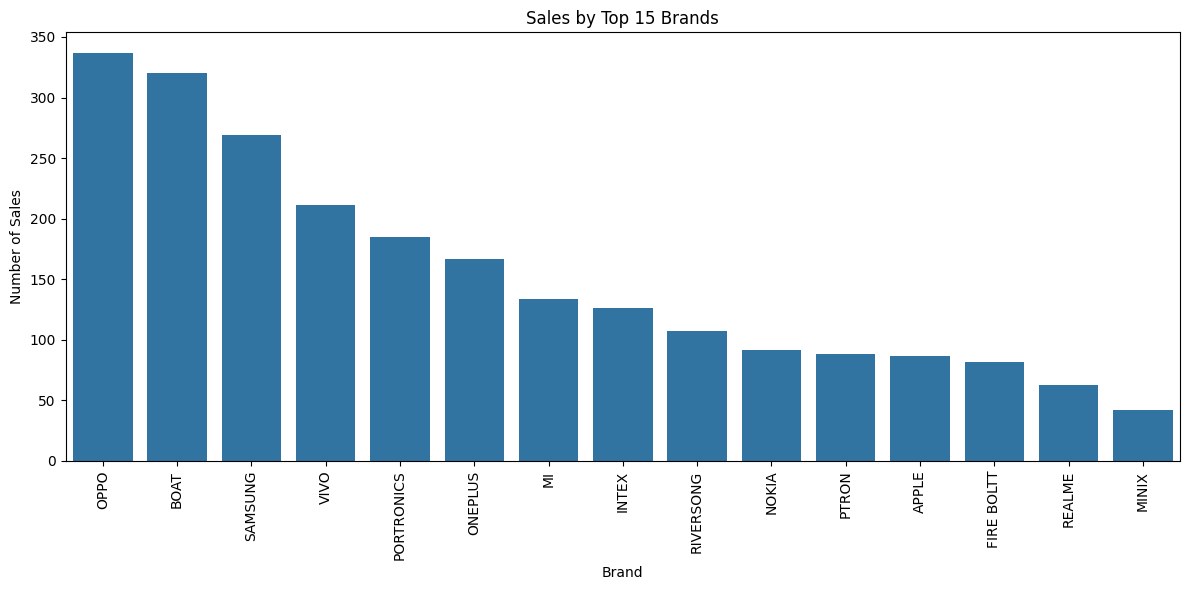

In [174]:
# Top 15 Brands
top_15_brands = df['BRAND'].value_counts().nlargest(15).index

# Filter the DataFrame to include only the top 15 brands
df_top_15 = df[df['BRAND'].isin(top_15_brands)]

plt.figure(figsize=(12, 6))
sns.countplot(x='BRAND', data=df_top_15, order=df_top_15['BRAND'].value_counts().index)
plt.xlabel('Brand')
plt.ylabel('Number of Sales')
plt.title('Sales by Top 15 Brands')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [175]:
import pandas as pd

# Assuming your DataFrame 'df' is already loaded and processed as in the provided code.

# Calculate RFM for each brand
today_date = pd.to_datetime('today')  # Use today's date as the reference point

rfm = df.groupby('BRAND').agg({
    'INV DATE': lambda x: (today_date - x.max()).days,  # Recency (days since last purchase)
    'INV NO': 'count',  # Frequency (number of invoices)
    'SALE PRICE(INC)': 'sum'  # Monetary value (total sales)
})

rfm.rename(columns={
    'INV DATE': 'Recency',
    'INV NO': 'Frequency',
    'SALE PRICE(INC)': 'MonetaryValue'
}, inplace=True)

rfm

,Recency,Frequency,MonetaryValue
BRAND,,,
APPLE,437,87,2967139
BOAT,432,320,402728
CONEKT,462,1,1500
DEFY,451,9,9
FIRE BOLTT,442,82,160339
GIZMORE,632,9,4999
HP,462,2,40001
INTEX,436,126,6313
ITEL,444,30,50676


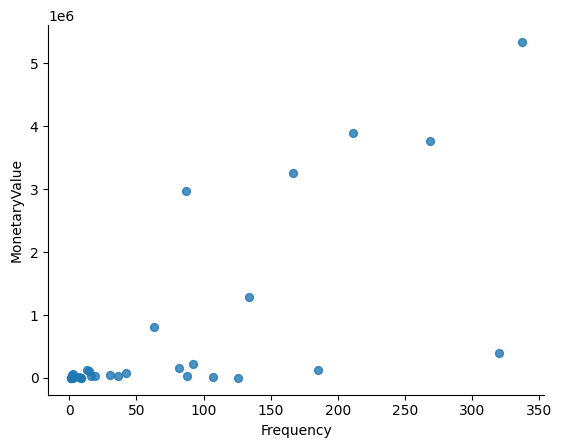

In [176]:
# title Frequency vs MonetaryValue

from matplotlib import pyplot as plt
rfm.plot(kind='scatter', x='Frequency', y='MonetaryValue', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

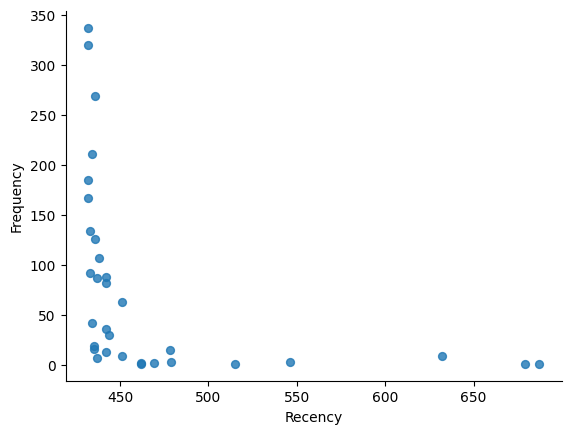

In [177]:
# title Recency vs Frequency

from matplotlib import pyplot as plt
rfm.plot(kind='scatter', x='Recency', y='Frequency', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

                      Recency  Frequency  MonetaryValue
CUSTOMER                                               
2.13E+14                  669          1            750
4                         634          1            600
A B BROTHERS              647          1          14499
A R DEORUKHKAR            580          1           1100
A REAL SOLUTIONS          488          1          88999
...                       ...        ...            ...
YOGESH PATIL              473          1          15000
YOGESH VASANT MISTRI      462          1          17499
YUVRAJ                    473          1           8000
ZAKHIR                    549          1           1300
ZAREENA                   557          1           1300

[1374 rows x 3 columns]


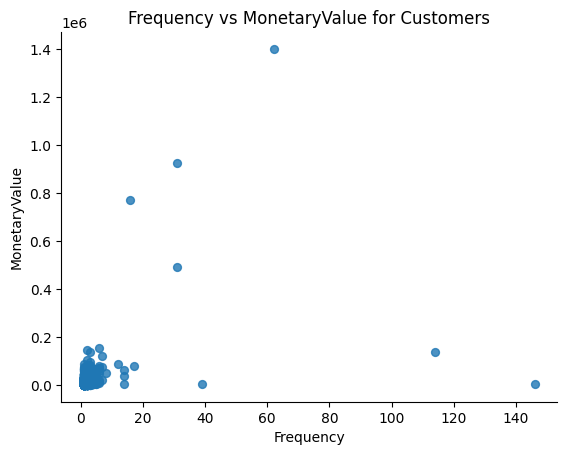

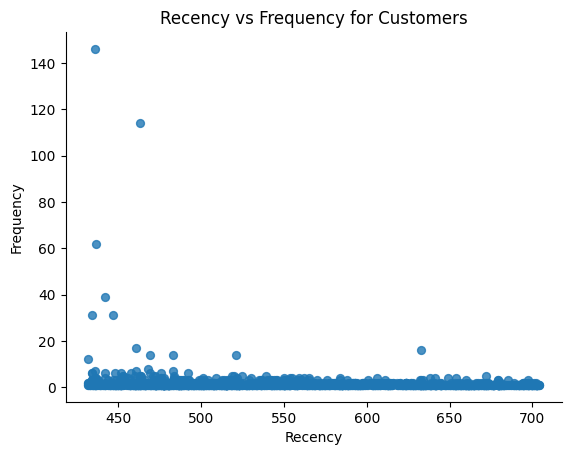

In [178]:
# Calculate RFM for each customer
today_date = pd.to_datetime('today')  # Use today's date as the reference point

rfm = df.groupby('CUSTOMER').agg({
    'INV DATE': lambda x: (today_date - x.max()).days,  # Recency (days since last purchase)
    'INV NO': 'count',  # Frequency (number of invoices)
    'SALE PRICE(INC)': 'sum'  # Monetary value (total sales)
})

rfm.rename(columns={
    'INV DATE': 'Recency',
    'INV NO': 'Frequency',
    'SALE PRICE(INC)': 'MonetaryValue'
}, inplace=True)

#Now you have RFM for each customer
print(rfm)

#You can further analyze and segment customers based on their RFM scores.
#Example: visualize the relationship between Frequency and MonetaryValue
rfm.plot(kind='scatter', x='Frequency', y='MonetaryValue', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.title('Frequency vs MonetaryValue for Customers')
plt.show()

#Example: visualize the relationship between Recency and Frequency
rfm.plot(kind='scatter', x='Recency', y='Frequency', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.title('Recency vs Frequency for Customers')
plt.show()

<ipython-input-179-aff0f460bf5b>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_profit_top10.index, y=brand_profit_top10.values, palette="viridis")


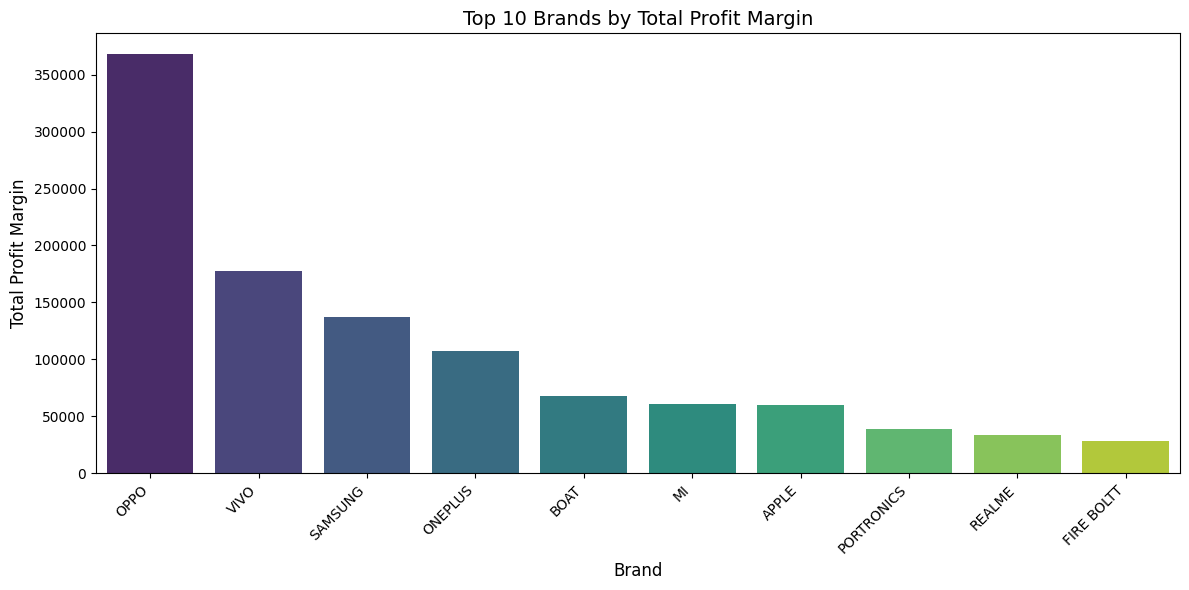

In [179]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by brand and sum the profit margin
brand_profit = df.groupby('BRAND')['PROFIT_M'].sum()

# Sort brands by profit in descending order and select the top 10
brand_profit_top10 = brand_profit.sort_values(ascending=False).head(10)

# Create the bar plot for the top 10 brands
plt.figure(figsize=(12, 6))
sns.barplot(x=brand_profit_top10.index, y=brand_profit_top10.values, palette="viridis")

# Labeling and Title
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Total Profit Margin', fontsize=12)
plt.title('Top 10 Brands by Total Profit Margin', fontsize=14)

# Rotating x-axis labels and adjusting for readability
plt.xticks(rotation=45, ha='right', fontsize=10)

# Ensure the layout is tight so everything fits
plt.tight_layout()

# Display the plot
plt.show()



MODEL
CPH 2495 A78 5G 8+128GB    82044.30600
CPH 2527 F23 5G 8+256GB    38360.19200
IPHONE 13 128GB            30349.99056
CPH 2565 A78 8+128GB       30204.63762
CPH 2477 A17 4+64GB        25340.39500
Name: PROFIT_M, dtype: float64


<ipython-input-180-cc618291204d>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_models.index, y=top_10_models.values, palette="coolwarm")


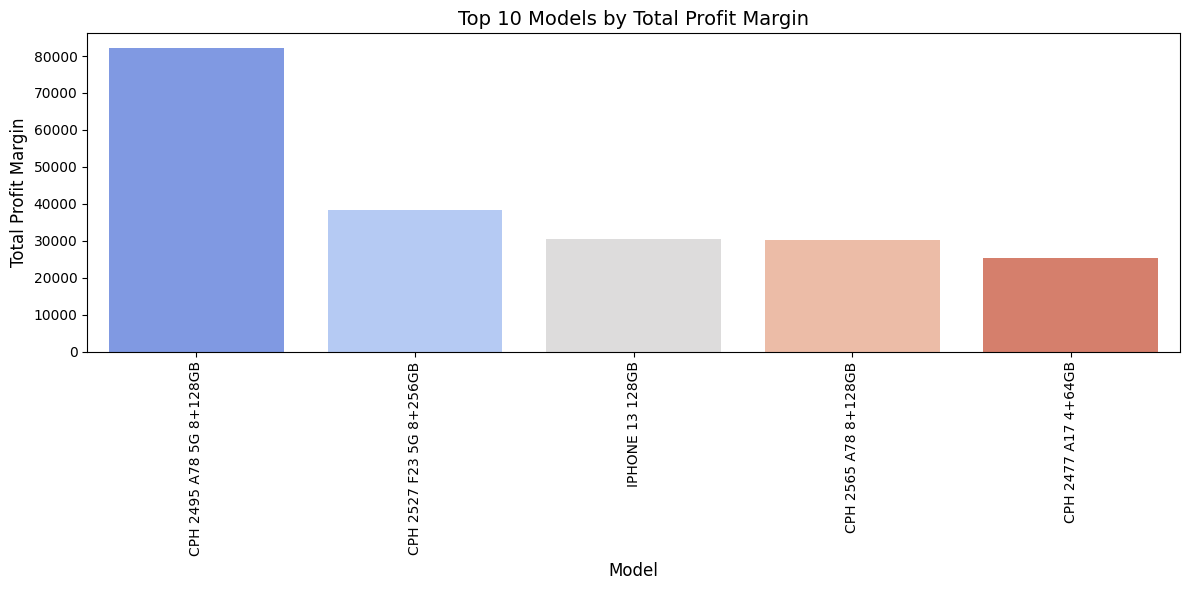

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by model and sum the profit margin
model_profit = df.groupby('MODEL')['PROFIT_M'].sum()

# Sort models by profit in descending order and get the top 5
top_10_models = model_profit.sort_values(ascending=False).head(5)

# Print the top 10 models and their profits
print(top_10_models)

# Create the bar plot to visualize the top 10 models
plt.figure(figsize=(12, 6))

# Use a color palette to beautify the plot
sns.barplot(x=top_10_models.index, y=top_10_models.values, palette="coolwarm")

# Labeling and Title
plt.xlabel('Model', fontsize=12)
plt.ylabel('Total Profit Margin', fontsize=12)
plt.title('Top 10 Models by Total Profit Margin', fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(rotation=90, fontsize=10)

# Adjust layout to ensure everything fits nicely
plt.tight_layout()

# Display the plot
plt.show()


# Break Even Point

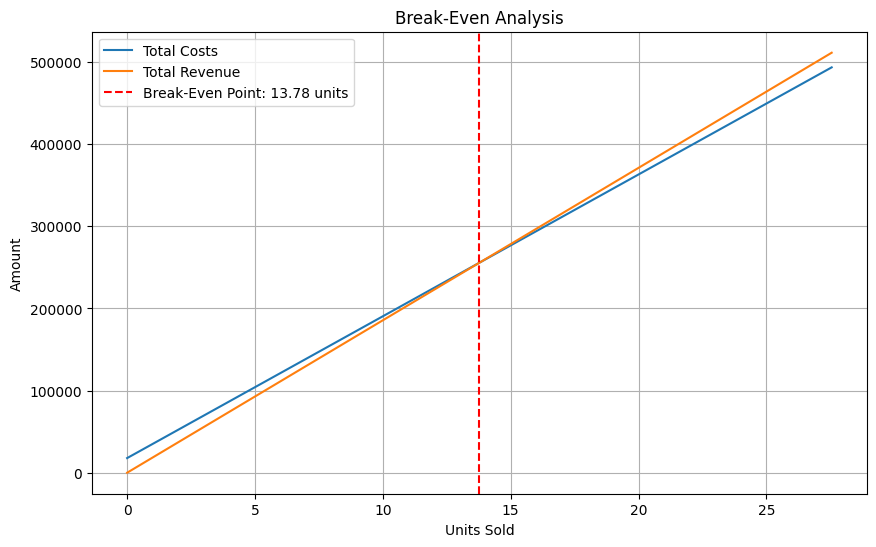

In [181]:
import matplotlib.pyplot as plt

fixed_costs = 17820
variable_costs_per_unit = 17262
selling_price_per_unit = 18555.63

# Calculate break-even point
break_even_point = fixed_costs / (selling_price_per_unit - variable_costs_per_unit)

# Generate x-axis values (units sold)
units_sold = np.linspace(0, 2 * break_even_point, 100)

# Calculate total costs
total_costs = fixed_costs + (variable_costs_per_unit * units_sold)

# Calculate total revenue
total_revenue = selling_price_per_unit * units_sold

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(units_sold, total_costs, label='Total Costs')
plt.plot(units_sold, total_revenue, label='Total Revenue')
plt.axvline(x=break_even_point, color='red', linestyle='--', label=f'Break-Even Point: {break_even_point:.2f} units')

# Add labels and title
plt.xlabel('Units Sold')
plt.ylabel('Amount')
plt.title('Break-Even Analysis')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [182]:
df.head()

,SR NO,INV NO,INV DATE,CUSTOMER,CATEGORY,BRAND,MODEL,COLOR,QUANTITY,SALE RATE,...,FINANCE,FINANCE NAME,SFID,WALLET NAME,CREDIT,PURCHASE DATE,STATUS,Give Away,DAYS IN STOCK,Month
0,1,T104/2292/22-23,2023-01-01,SHEKHER,SMART WATCH,PTRON,PULSEFIT P261,BLACK GOLD,1,1355.08,...,0,NaN,NaN,NaN,0,2022-12-05,B to C,0.00000,27,2023-01
1,3,T104/2294/22-23,2023-01-01,MADHUPAL,MOBILE,OPPO,CPH 2455 F21S PRO 5G 8+128GB,DAWNLIGHT GOLD,1,21186.44,...,0,NaN,NaN,NaN,0,2022-12-07,B to C,0.00000,25,2023-01
2,4,T104/2295/22-23,2023-01-01,SALE CASH,ACCESSORIES,RIVERSONG,EA59 MELODY J,NONE,1,0.85,...,0,NaN,NaN,NaN,0,2022-12-20,B to C,64.11998,12,2023-01
3,2,T104/2293/22-23,2023-01-01,VISHAL TAKKEKAR,MOBILE,MI,REDMI A1+ 2+32GB,BLACK,1,6355.08,...,7299,HDB FINANCIAL,1.07E+11,NaN,0,2022-11-16,B to C,0.00000,46,2023-01
4,6,T104/2297/22-23,2023-01-02,PARMILA,ACCESSORIES,SANDISK,32GB ULTRA 120MB/S A1,NONE,1,338.98,...,0,NaN,NaN,NaN,0,2022-08-12,B to C,0.00000,143,2023-01


**Promotion Planning**

In [183]:
print(df['Give Away'].sum())

270151.21119999996


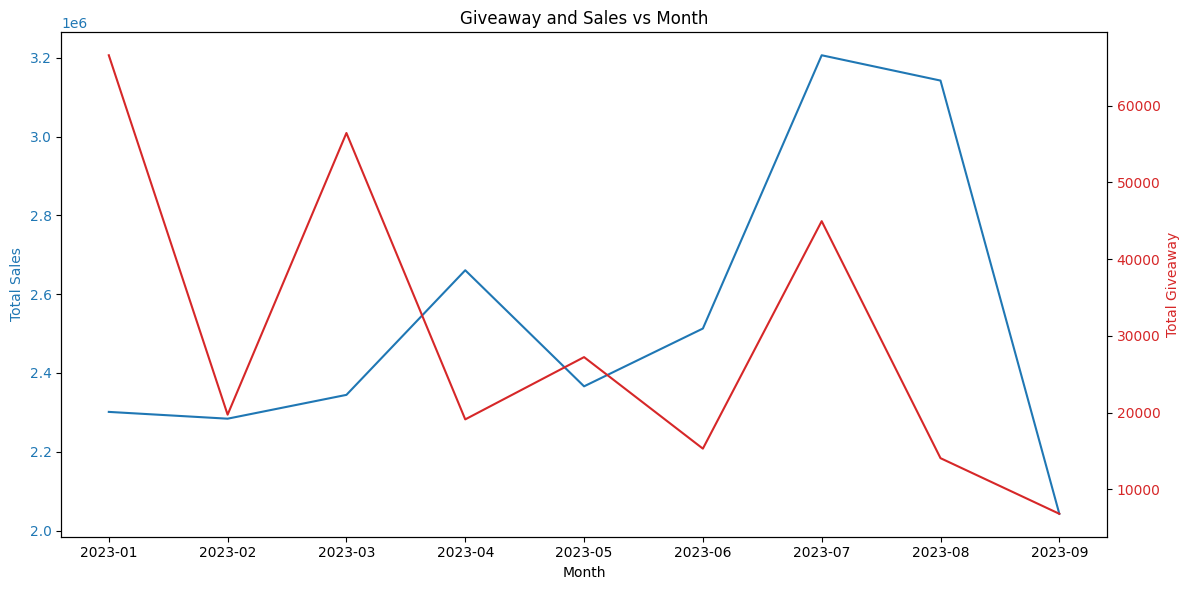

In [184]:

import matplotlib.pyplot as plt

# Create a 'Month' column from the 'INV DATE' column if not already done
if 'Month' not in df.columns:
    df['Month'] = df['INV DATE'].dt.to_period('M')

# Group by month and sum 'Give Away' and 'SALE PRICE(INC)'
monthly_data = df.groupby('Month').agg({'Give Away': 'sum', 'SALE PRICE(INC)': 'sum'})

# Create the dual-axis plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot 'SALE PRICE(INC)' on the first axis
color = 'tab:blue'
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Sales', color=color)
ax1.plot(monthly_data.index.astype(str), monthly_data['SALE PRICE(INC)'], color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Create a second axis sharing the same x-axis
ax2 = ax1.twinx()

# Plot 'Give Away' on the second axis
color = 'tab:red'
ax2.set_ylabel('Total Giveaway', color=color)
ax2.plot(monthly_data.index.astype(str), monthly_data['Give Away'], color=color)
ax2.tick_params(axis='y', labelcolor=color)

# Customize the plot
plt.title('Giveaway and Sales vs Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<ipython-input-185-836daff863a4>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


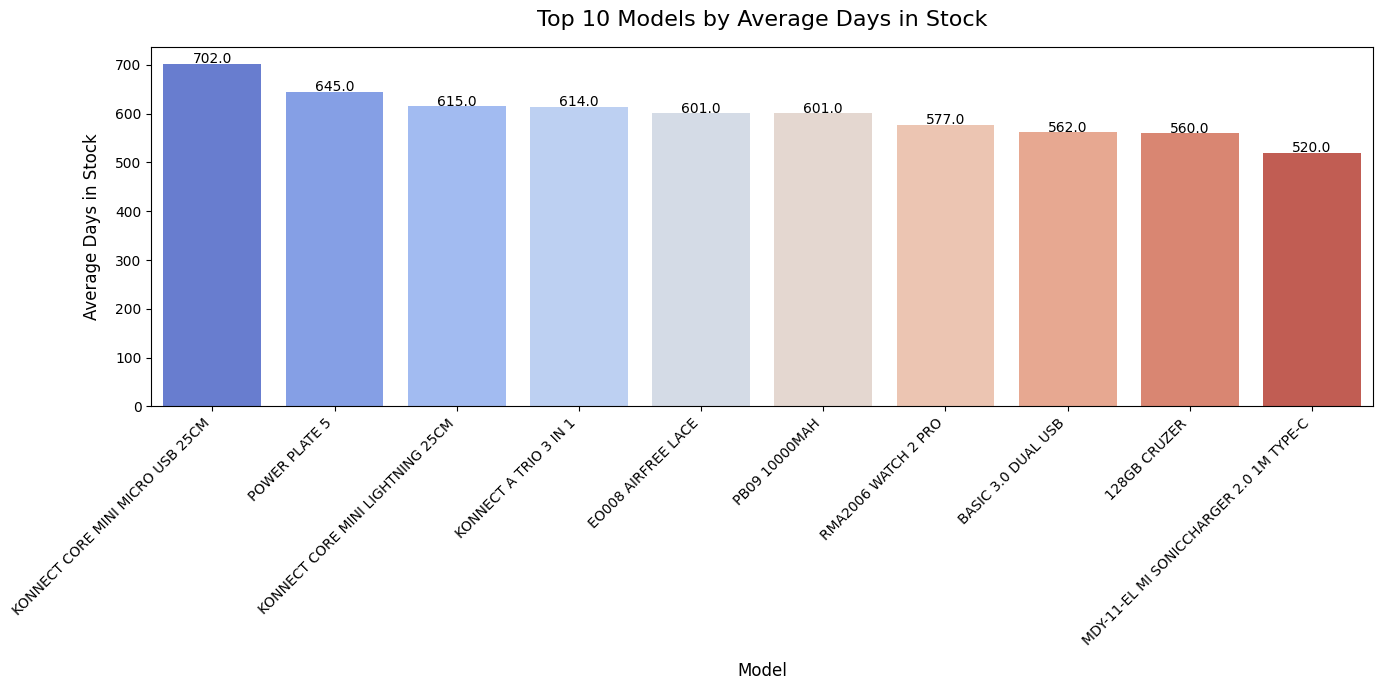

In [185]:
# Group by model and calculate the mean of 'DAYS IN STOCK'
model_days_in_stock = df.groupby('MODEL')['DAYS IN STOCK'].mean()

# Sort models by 'DAYS IN STOCK' in descending order and get the top 10
top_10_models_days_in_stock = model_days_in_stock.sort_values(ascending=False).head(10)

# Import necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Create the bar plot
plt.figure(figsize=(14, 7))  # Adjust figure size for better readability
sns.barplot(
    x=top_10_models_days_in_stock.index,
    y=top_10_models_days_in_stock.values,
    palette="coolwarm"  # Apply a visually appealing color palette
)

# Add labels and title
plt.xlabel('Model', fontsize=12, labelpad=10)
plt.ylabel('Average Days in Stock', fontsize=12, labelpad=10)
plt.title('Top 10 Models by Average Days in Stock', fontsize=16, pad=15)

# Add value labels to each bar
for index, value in enumerate(top_10_models_days_in_stock.values):
    plt.text(index, value + 1, f'{value:.1f}', ha='center', fontsize=10)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, fontsize=10, ha='right')

# Tight layout for cleaner display
plt.tight_layout()

# Show the plot
plt.show()


In [186]:
df = df.drop(['SR NO','INV NO','INV DATE','CUSTOMER','COLOR','QUANTITY','Unnamed: 20','CASH','CHEQUE','CREDIT/DEBIT CARD','WALLET','FINANCE NAME','SFID','WALLET NAME','CREDIT','PURCHASE DATE'], axis=1)

In [187]:
df = df.drop(['Month'], axis=1)

In [188]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2478 entries, 0 to 2477
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CATEGORY            2478 non-null   object 
 1   BRAND               2478 non-null   object 
 2   MODEL               2478 non-null   object 
 3   SALE RATE           2478 non-null   float64
 4   SALE PRICE(INC)     2478 non-null   int64  
 5   PURCHASE PRICE(PD)  2478 non-null   float64
 6   PROFIT_M            2478 non-null   float64
 7   FINANCE             2478 non-null   int64  
 8   STATUS              2478 non-null   object 
 9   Give Away           2478 non-null   float64
 10  DAYS IN STOCK       2478 non-null   int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 213.1+ KB


In [189]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder object
le = LabelEncoder()

# Iterate through each column in the DataFrame
for col in df.columns:
    # Check if the column's data type is 'object' (categorical)
    if df[col].dtype == 'object':
        # Fit the LabelEncoder to the unique values in the column
        le.fit(df[col].astype(str).unique())  # Convert to string to handle mixed types
        # Transform the column using the fitted LabelEncoder
        df[col] = le.transform(df[col].astype(str))

# Now, all categorical columns in your DataFrame 'df' have been converted to numerical representations.
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2478 entries, 0 to 2477
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CATEGORY            2478 non-null   int64  
 1   BRAND               2478 non-null   int64  
 2   MODEL               2478 non-null   int64  
 3   SALE RATE           2478 non-null   float64
 4   SALE PRICE(INC)     2478 non-null   int64  
 5   PURCHASE PRICE(PD)  2478 non-null   float64
 6   PROFIT_M            2478 non-null   float64
 7   FINANCE             2478 non-null   int64  
 8   STATUS              2478 non-null   int64  
 9   Give Away           2478 non-null   float64
 10  DAYS IN STOCK       2478 non-null   int64  
dtypes: float64(4), int64(7)
memory usage: 213.1 KB
None


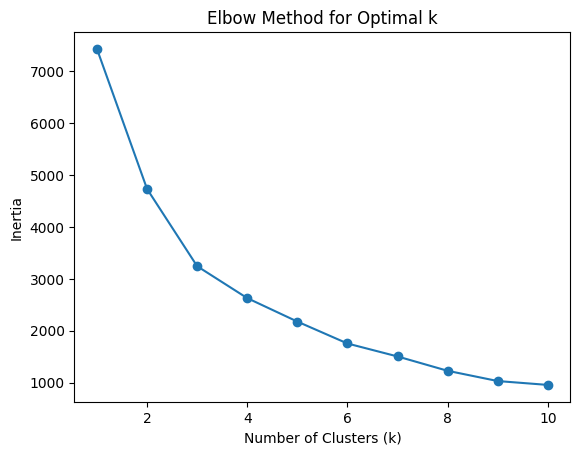

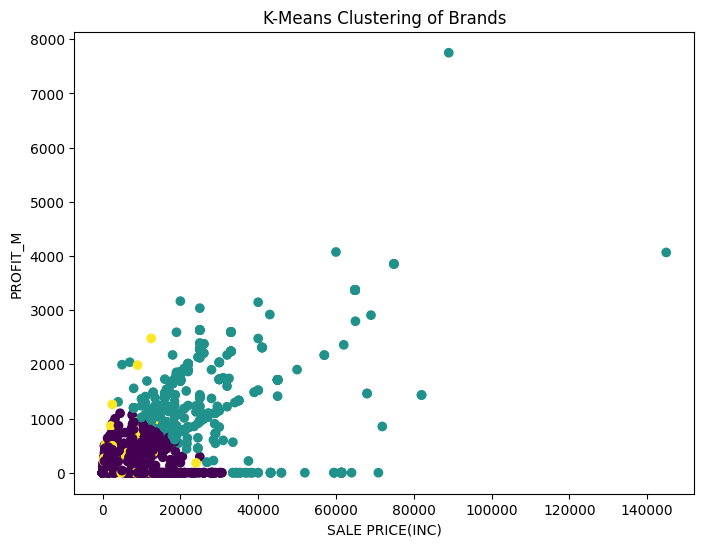

In [190]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame and it's already loaded and processed as in the provided code.
# Select features for clustering (replace with your desired features)
features = ['SALE PRICE(INC)', 'PROFIT_M', 'DAYS IN STOCK']  # Example features
X = df[features]


# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine the optimal number of clusters (k) using the Elbow method (optional)
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()


# Apply k-means clustering with the chosen k
k = 3  # Example: Choose the optimal k from the elbow method or other methods
kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Visualize the clusters (example with 2 features)
plt.figure(figsize=(8, 6))
plt.scatter(df[features[0]], df[features[1]], c=df['cluster'], cmap='viridis')
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title('K-Means Clustering of Brands')
plt.show()

Mean Squared Error: 25293.207779275086
R-squared: 0.9401224980344691
                    CATEGORY     BRAND     MODEL  SALE RATE  SALE PRICE(INC)  \
CATEGORY            1.000000  0.233445  0.190349   0.416707         0.421882   
BRAND               0.233445  1.000000  0.331046   0.170229         0.175128   
MODEL               0.190349  0.331046  1.000000   0.134845         0.134779   
SALE RATE           0.416707  0.170229  0.134845   1.000000         0.996592   
SALE PRICE(INC)     0.421882  0.175128  0.134779   0.996592         1.000000   
PURCHASE PRICE(PD)  0.416781  0.172107  0.142817   0.995482         0.997072   
PROFIT_M            0.337131  0.182013  0.012116   0.558841         0.595322   
FINANCE             0.159371  0.072108  0.040108   0.452514         0.475665   
STATUS             -0.145438 -0.078857 -0.101164  -0.375598        -0.322695   
Give Away           0.042285  0.038292  0.098422   0.084071         0.082805   
DAYS IN STOCK      -0.194993  0.070245 -0.036835  -

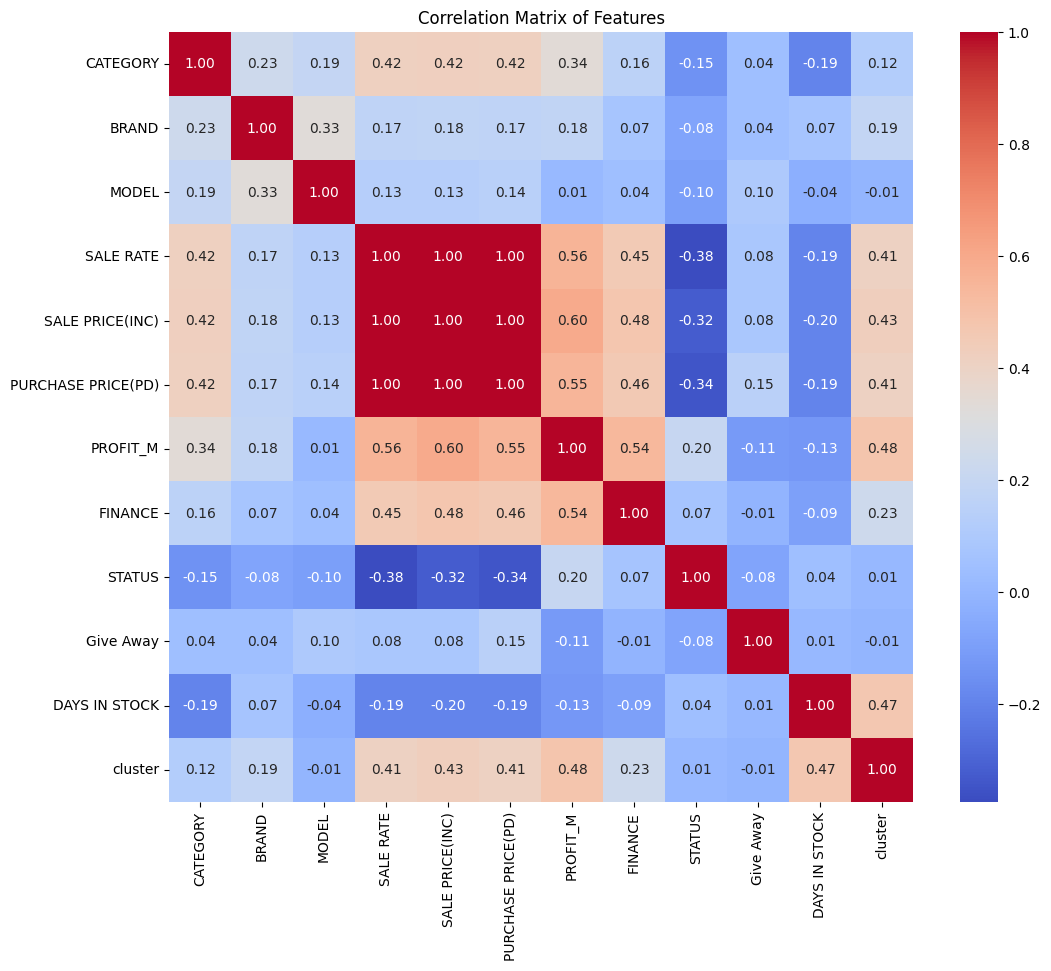

In [191]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Assuming 'df' is your DataFrame and it's already loaded and processed.

# Define features (X) and target variable (y)
X = df.drop('PROFIT_M', axis=1)  # Replace 'target_column' with the actual column name
y = df['PROFIT_M']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42) # You can adjust n_estimators
rf_regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_regressor.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

#Correlation Matrix
correlation_matrix = df.corr()
print(correlation_matrix)

#Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()